In [5]:
import numpy as np

# ----------------------------------------
# 1. 유클리드 거리 함수
# ----------------------------------------


def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# ----------------------------------------
# 2. KNN 예측 함수
# ----------------------------------------


def knn_predict(x, X_train, y_train, k):
    distances = [euclidean_distance(x, xi) for xi in X_train]
    k_indices = np.argsort(distances)[:k]
    k_labels = y_train[k_indices]

    # 다수결
    labels, counts = np.unique(k_labels, return_counts=True)
    return labels[np.argmax(counts)]

# ----------------------------------------
# 3. 정확도 평가 함수
# ----------------------------------------


def compute_accuracy(X_val, y_val, X_train, y_train, k):
    correct = 0
    for x, y in zip(X_val, y_val):
        pred = knn_predict(x, X_train, y_train, k)
        if pred == y:
            correct += 1
    return correct / len(y_val)


# ----------------------------------------
# 4. 데이터 예시
# ----------------------------------------
X = np.array([
    [1.0, 2.0], [1.5, 1.8], [5.0, 8.0],
    [6.0, 9.0], [1.0, 0.6], [9.0, 11.0],
    [8.0, 2.0], [10.0, 2.0], [9.0, 3.0]
])
y = np.array(['A', 'A', 'B', 'B', 'A', 'B', 'B', 'B', 'B'])

# ----------------------------------------
# 5. 훈련/검증 데이터 분할
# ----------------------------------------
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.7 * len(X))

train_idx = indices[:split]
val_idx = indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

# ----------------------------------------
# 6. k값 최적화
# ----------------------------------------
k_candidates = range(1, 40)
best_k = None
best_acc = 0.0

print("k값별 정확도:")
for k in k_candidates:
    acc = compute_accuracy(X_val, y_val, X_train, y_train, k)
    print(f"k = {k} → 정확도: {acc:.2f}")
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"\n✅ 최적의 k값은: {best_k} (정확도: {best_acc:.2f})")


k값별 정확도:
k = 1 → 정확도: 1.00
k = 2 → 정확도: 1.00
k = 3 → 정확도: 1.00
k = 4 → 정확도: 1.00
k = 5 → 정확도: 0.67
k = 6 → 정확도: 0.67
k = 7 → 정확도: 0.67
k = 8 → 정확도: 0.67
k = 9 → 정확도: 0.67
k = 10 → 정확도: 0.67
k = 11 → 정확도: 0.67
k = 12 → 정확도: 0.67
k = 13 → 정확도: 0.67
k = 14 → 정확도: 0.67
k = 15 → 정확도: 0.67
k = 16 → 정확도: 0.67
k = 17 → 정확도: 0.67
k = 18 → 정확도: 0.67
k = 19 → 정확도: 0.67
k = 20 → 정확도: 0.67
k = 21 → 정확도: 0.67
k = 22 → 정확도: 0.67
k = 23 → 정확도: 0.67
k = 24 → 정확도: 0.67
k = 25 → 정확도: 0.67
k = 26 → 정확도: 0.67
k = 27 → 정확도: 0.67
k = 28 → 정확도: 0.67
k = 29 → 정확도: 0.67
k = 30 → 정확도: 0.67
k = 31 → 정확도: 0.67
k = 32 → 정확도: 0.67
k = 33 → 정확도: 0.67
k = 34 → 정확도: 0.67
k = 35 → 정확도: 0.67
k = 36 → 정확도: 0.67
k = 37 → 정확도: 0.67
k = 38 → 정확도: 0.67
k = 39 → 정확도: 0.67
k = 40 → 정확도: 0.67
k = 41 → 정확도: 0.67
k = 42 → 정확도: 0.67
k = 43 → 정확도: 0.67
k = 44 → 정확도: 0.67
k = 45 → 정확도: 0.67
k = 46 → 정확도: 0.67
k = 47 → 정확도: 0.67
k = 48 → 정확도: 0.67
k = 49 → 정확도: 0.67

✅ 최적의 k값은: 1 (정확도: 1.00)


/var/folders/mx/t0qyyp950q77yn6fmz_95r_40000gn/T/ipykernel_34417/1557475994.py:38: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/jeonghs215/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


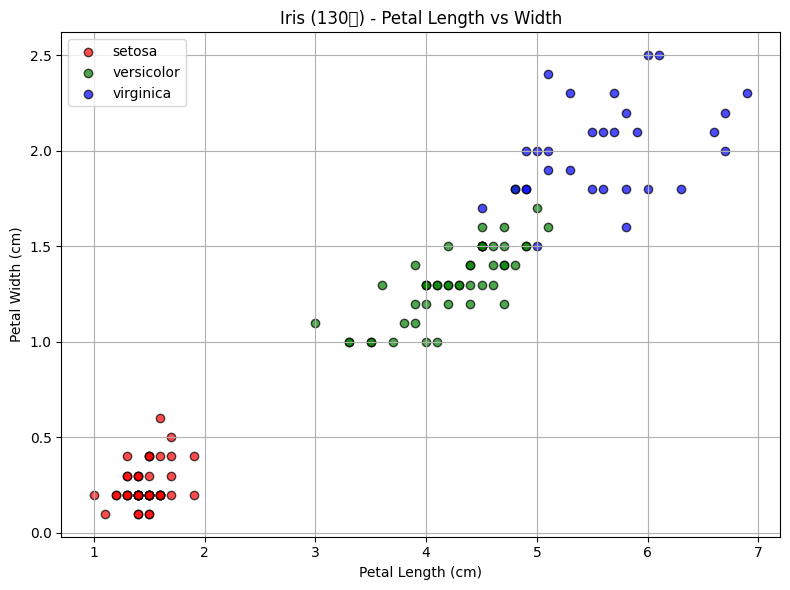

In [11]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# 데이터 준비
# ----------------------------------------
iris = load_iris()
x = iris.data[:130, [2, 3]]  # 꽃잎 길이, 너비
y = iris.target[:130]

df = pd.DataFrame(x, columns=["Petal Length", "Petal Width"])
df["Label"] = y

# ----------------------------------------
# 시각화
# ----------------------------------------
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
labels = iris.target_names  # ['setosa', 'versicolor', 'virginica']

for i in range(3):
    subset = df[df["Label"] == i]
    plt.scatter(
        subset["Petal Length"],
        subset["Petal Width"],
        color=colors[i],
        label=labels[i],
        alpha=0.7,
        edgecolor='k'
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris (130개) - Petal Length vs Width")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
